# 在这里我们把物理学和渲染器合到一起，变成一个环境。

In [6]:
import drone_dynamics
from drone_renderer import *
import torch
import matplotlib.pyplot as plt
import cv2 
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')



# 要做Env我们要先引入物理核心

In [ ]:
# device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# renderer = DroneRenderer(
#     mesh_path="./data/sample/sample.obj",
#     image_size=(480, 640),
#     focal_length=500.0
# )


# # 1. 初始化
# B = 1
# steps = 100
# dt = 0.02

# # 状态变量
# p = torch.tensor([0.0,0.0,100.0], device=device).unsqueeze(0).repeat(B, 1)  # 位置
# # p = torch.zeros((B, 3), device=device)       # 位置
# v = torch.zeros((B, 3), device=device)       # 速度
# a = torch.zeros((B, 3), device=device)       # 加速度
# R = torch.eye(3, device=device).unsqueeze(0).repeat(B, 1, 1) # 初始姿态
# act = torch.zeros((B, 3), device=device) + torch.tensor([0,0,0],device=device).repeat(B,1)     # 实际推力(加速度形式)
# dg = torch.randn((B, 3), device=device) * 0.1 # 初始化扰动 
# # 期望控制量 (假设我们要悬停，只有重力补偿)

# act_pred = torch.zeros((B, 3), device=device) # 期望合加速度为0 (悬停)

# # goal_position shape: (B, 3)
# goal_position = torch.tensor([0,0,100], dtype=torch.float32, device=device).unsqueeze(0).repeat(B, 1)
# # Gravity vector
# g = torch.tensor([0.0, 0.0, -9.80665], device=device).unsqueeze(0).repeat(B,1)

# print(goal_position.shape)
# # 记录轨迹
# traj_p = []
# traj_dg = []
# # 初始化 R_new
# R_new = R
# for i in range(steps):
#     # 模拟一步动力学
#     # 可以在这里控制 enable_airmode 和 enable_induced_drag
#     p, v, a, act = drone_dynamics.simulate_position_step(
#         p, v, a, act, act_pred, R, dt, 
#         dg=None, # 传入当前的 dg
#         enable_airmode=True,       # 开启 Airmode
#         enable_induced_drag=False,  # 关闭 H-force (默认配置)
#         grad_decay=0.99            # 梯度衰减系数，防止长序列梯度爆炸
#     )
    
#     # 计算用于姿态反解的“净推力向量” (Thrust Only)
#     # act 包含了重力 (Net Acc = Thrust + Gravity)，所以 Thrust = act - Gravity
#     thrust_vec_only = act - g # [0,0,0] - [0,0,-9.8] = [0,0,9.8] (Upwards)

#     # 如果推力过小（例如自由落体），保持上一时刻姿态或者默认向上
#     # 这里加一个保护，防止 divide by zero
#     if thrust_vec_only.norm(dim=1).min() < 1e-6:
#         thrust_vec_only = thrust_vec_only + torch.tensor([0,0,1.0], device=device) * 1e-6
        
#     # goal_vec refers to the direction towards the goal
#     goal_vec = goal_position - p
    
#     # 反解姿态
#     R_new = drone_dynamics.solve_attitude_from_thrust_and_goal_vec(
#         thrust_vector= thrust_vec_only,
#         velocity= goal_vec,
#         R_old= R_new,
#         dt= 0.02
#     )
    
#     # 使用新的接口渲染: 直接传入 ENU 坐标系下的姿态和位置
#     rgb_batch, depth_batch = renderer.render_drone_view(R_new, p)
    
#     # Visualization using OpenCV
#     # Convert Torch Tensor to Numpy Array (CPU)
#     # Take the first drone in the batch [0]
#     img_rgb = rgb_batch[0].detach().cpu().numpy()
#     img_depth = depth_batch[0].detach().cpu().numpy()
    
#     # Convert RGB to BGR for OpenCV
#     img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    
#     # Parse depth for better visualization (normalize to 0-1 or just show raw if range is fine)
#     # Here uses raw depth map
#     cv2.imshow("RGB", img_bgr)
#     cv2.imshow("Depth", img_depth / 10.0) # Scale depth for better visibility
#     cv2.waitKey(20) # Important for OpenCV window to update

#     # 更新扰动
#     dg = drone_dynamics.update_dg(dg, dt)
    

#     traj_p.append(p.clone())
#     traj_dg.append(dg.clone())
# cv2.destroyAllWindows()

In [8]:
# 初始化渲染器
renderer = DroneRenderer(
    mesh_path="./data/sample/sample.obj",
    image_size=(480, 640),
    focal_length=500.0
)

P_pytorch: tensor([[ -0.,   0.,   0.],
        [ -0., 100.,   0.],
        [ -0., 110.,   0.],
        [ -0., 120.,   0.]], device='cuda:0')
R_pytorch: tensor([[[-1., -0., -0.],
         [ 0.,  0.,  1.],
         [ 0.,  1.,  0.]],

        [[-1., -0., -0.],
         [ 0.,  0.,  1.],
         [ 0.,  1.,  0.]],

        [[-1., -0., -0.],
         [ 0.,  0.,  1.],
         [ 0.,  1.,  0.]],

        [[-1., -0., -0.],
         [ 0.,  0.,  1.],
         [ 0.,  1.,  0.]]], device='cuda:0')
P_pytorch shape: torch.Size([4, 3])
R_pytorch shape: torch.Size([4, 3, 3])
Rendered RGB batch shape: torch.Size([4, 480, 640, 3])
Rendered Depth batch shape: torch.Size([4, 480, 640])


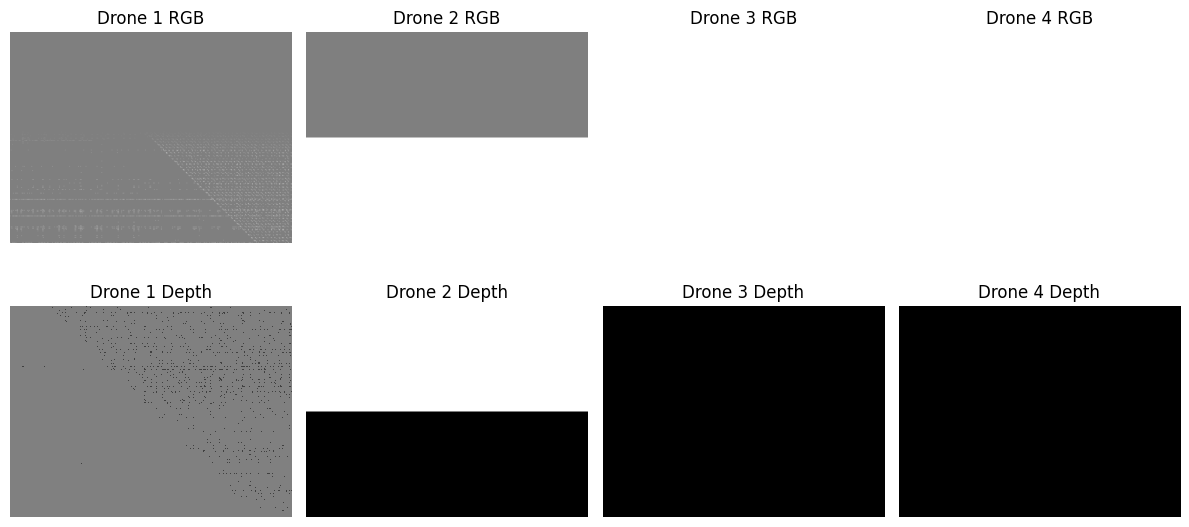

In [ ]:
# 批量化初始化位置
B = 4
P_ENU = torch.tensor([[0.0,0.0,0.0],
                  [0.0,0.0,100.0],
                  [0.0,0.0,110.0],
                  [0.0,0.0,120.0]], device=device)  # 位置
R_ENU = torch.eye(3, device=device).unsqueeze(0).repeat(B, 1, 1)  # 姿态
# 指向世界坐标系 x 轴正方向


# 使用 render_drone_view 简化渲染调用
# 无需手动调用 transform_pos_ros2pt3d 等函数
rgb_batch, depth_batch = renderer.render_drone_view(R_ENU, P_ENU)

print("Rendered RGB batch shape:", rgb_batch.shape)
print("Rendered Depth batch shape:", depth_batch.shape)
# 可视化渲染结果
plt.figure(figsize=(12, 6))
for i in range(B):
    plt.subplot(2, B, i+1)
    plt.imshow(rgb_batch[i].cpu().numpy())
    plt.title(f'Drone {i+1} RGB')
    plt.axis('off')
    
    plt.subplot(2, B, i+1+B)
    plt.imshow(depth_batch[i].cpu().numpy(), cmap='gray')
    plt.title(f'Drone {i+1} Depth')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 交互式可视化调试工具 (Keyboard Control)
# 使用方法:
#   W/S: 前进/后退 (沿当前视角 Body Forward)
#   A/D: 向左/向右 (沿当前视角 Body Right/Left)
#   Q/E: 升高/降低 (垂直 Z 轴 - World Up/Down)
#   Up/Down (方向键): 抬头/低头 (Pitch)
#   Left/Right (方向键): 左转/右转 (Yaw)
#   ESC: 退出

import cv2
import numpy as np
import torch

def get_rotation_matrix_ros(yaw_deg, pitch_deg):
    """根据 Yaw, Pitch 构建 ROS 坐标系下的旋转矩阵 (Body -> World)"""
    yaw = np.deg2rad(yaw_deg)
    pitch = np.deg2rad(pitch_deg)
    
    # Rz (Yaw)
    cz, sz = np.cos(yaw), np.sin(yaw)
    Rz = torch.tensor([[cz, -sz, 0],
                       [sz,  cz, 0],
                       [0,   0, 1]], device=device, dtype=torch.float32)
                       
    # Ry (Pitch) - Body Frame Y axis
    cy, sy = np.cos(pitch), np.sin(pitch)
    Ry = torch.tensor([[cy, 0, sy],
                       [0, 1, 0],
                       [-sy, 0, cy]], device=device, dtype=torch.float32)
    
    # R = Rz @ Ry (Yaw first then Pitch)
    return Rz @ Ry

# 1. 状态初始化
cam_pos_ros = torch.tensor([0.0, 0.0, 100.0], device=device, dtype=torch.float32) # ENU
cam_yaw = 0.0   # Degree, 0 = Face East (+X)
cam_pitch = 0.0 # Degree
speed_move = 5.0 # Speed up movement for searching
speed_rot = 2.0

print("Starting Interactive Debugger... Press ESC to exit.")
print("OpenCV window must be focused for controls to work.")

try:
    while True:
        # --- 1. 计算当前 Pose ---
        # 构建旋转矩阵 (Body -> World in ROS)
        R_ros = get_rotation_matrix_ros(cam_yaw, cam_pitch)
        
        # --- 2. 渲染 (使用封装好的 render_drone_view) ---
        with torch.no_grad():
            # 需要扩展维度为 (1, ...)
            rgb_batch, depth_batch = renderer.render_drone_view(R_ros.unsqueeze(0), cam_pos_ros.unsqueeze(0))
            
        # --- 3. 显示 ---
        img_rgb = rgb_batch[0].cpu().numpy()
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        
        # 添加文字信息 (ROS 坐标)
        info_text = f"Pos(ENU): [{cam_pos_ros[0]:.1f}, {cam_pos_ros[1]:.1f}, {cam_pos_ros[2]:.1f}]"
        angle_text = f"Yaw: {cam_yaw:.1f}, Pitch: {cam_pitch:.1f}"
        cv2.putText(img_bgr, info_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.putText(img_bgr, angle_text, (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        cv2.imshow("Debugger (WASD, Arrows, QE)", img_bgr)
        
        # --- 4. 控制 ---
        key = cv2.waitKey(30)
        if key == 27: # ESC
            break
            
        # 移动向量计算 (ROS 坐标系)
        # 注意: 这里的移动是相对于“世界水平面”的，方便探索地图
        rad = np.deg2rad(cam_yaw)
        forward_vec = torch.tensor([np.cos(rad), np.sin(rad), 0.0], device=device) # Level Forward
        right_vec = torch.tensor([np.sin(rad), -np.cos(rad), 0.0], device=device)  # Level Right (South if East-facing)
        
        if key == ord('w'): # Forward
            cam_pos_ros += forward_vec * speed_move
        elif key == ord('s'): # Backward
            cam_pos_ros -= forward_vec * speed_move
        elif key == ord('a'): # Left
            cam_pos_ros -= right_vec * speed_move # 修正: 向左移动
        elif key == ord('d'): # Right
            cam_pos_ros += right_vec * speed_move
            
        if key == ord('q'): # Up
            cam_pos_ros[2] += speed_move
        elif key == ord('e'): # Down
            cam_pos_ros[2] -= speed_move
            
        # 旋转
        if key == 82: cam_pitch += speed_rot
        elif key == 84: cam_pitch -= speed_rot
        elif key == 81: cam_yaw += speed_rot
        elif key == 83: cam_yaw -= speed_rot
        
        if key == ord('i'): cam_pitch += speed_rot
        if key == ord('k'): cam_pitch -= speed_rot
        if key == ord('j'): cam_yaw += speed_rot
        if key == ord('l'): cam_yaw -= speed_rot

except KeyboardInterrupt:
    pass
finally:
    cv2.destroyAllWindows()

Starting Interactive Debugger... Press ESC to exit.
OpenCV window must be focused for controls to work.
